# Regression Trees & Random Forest Regression

## Libraries and settings

In [60]:
# Libraries
import os
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

C:\Dev\Studium\Sem5\DA\data_analytics\Week_08


## Import the apartment data

In [61]:
# Define columns for import
columns = [ 'web-scraper-order',
            'address_raw',
            'rooms',
            'area',
            'luxurious',
            'price',
            'price_per_m2',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp',
            'mean_taxable_income',
            'dist_supermarket']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", sep=";", encoding='utf-8')[columns]

# Rename variable 'web-scraper-order' to 'apmt_id'
df_orig = df_orig.rename(columns={'web-scraper-order': 'id'})

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()

# Remove some 'extreme' values
df = df.loc[(df['price'] >= 1000) & 
            (df['price'] <= 5000)]

# Reset index
df = df.reset_index(drop=True)

print(df.shape)
df.head(5)

(722, 17)


,id,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49,0,1441,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",3.0,111,0,2600,23.42,47.252087,8.854919,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",3.0,58,0,1490,25.69,47.253670,8.853993,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",4.0,118,0,3240,27.46,47.259834,8.851705,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",3.0,66,0,1450,21.97,47.266113,8.866872,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,974.844209


## Regression Tree
See also: https://data36.com/regression-tree-python-scikit-learn

### Create train and test samples for the regression tree (train = 80%, test = 20% of the data)

In [62]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df[['area', 
                                                        'rooms',
                                                        'pop_dens',
                                                        'mean_taxable_income',
                                                        'dist_supermarket']], 
                                                        df['price'], 
                                                        test_size=0.20, 
                                                        random_state=42)

# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
     area  rooms     pop_dens  mean_taxable_income  dist_supermarket
456   120    6.5   165.018625          65380.98802       1958.318650
6      65    3.5   525.662252         111422.35870        282.095910
362    90    3.5   424.146342          72133.75058       2606.231069
594    63    2.5  1044.628957          70964.08794        564.607066
439    91    3.5   399.525129          62000.54187        646.823905 

y_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the regression tree model

In [63]:
# Create decision tree regressor object
reg = DecisionTreeRegressor(random_state=20, max_depth=3)

# Train decision tree regressor
reg = reg.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = reg.predict(X_test)

### Calculate coefficient of determination (R-squared)

In [64]:
# Calculate coefficient of determination, round to 4 decimals
print(f'R-squared:, {r2_score(y_test, y_pred):.4f}')

R-squared:, 0.4502


### Print text representation of the regression tree

In [65]:
# Text representation of the regression tree
text_representation = tree.export_text(reg, 
                                       feature_names=list(X_train.columns))

# Print text_representation
print(text_representation)

|--- area <= 99.50
|   |--- pop_dens <= 4269.10
|   |   |--- area <= 77.50
|   |   |   |--- value: [1722.86]
|   |   |--- area >  77.50
|   |   |   |--- value: [2191.39]
|   |--- pop_dens >  4269.10
|   |   |--- area <= 52.50
|   |   |   |--- value: [1893.80]
|   |   |--- area >  52.50
|   |   |   |--- value: [2927.78]
|--- area >  99.50
|   |--- area <= 134.00
|   |   |--- pop_dens <= 3874.83
|   |   |   |--- value: [2672.06]
|   |   |--- pop_dens >  3874.83
|   |   |   |--- value: [3603.59]
|   |--- area >  134.00
|   |   |--- pop_dens <= 1663.59
|   |   |   |--- value: [3391.42]
|   |   |--- pop_dens >  1663.59
|   |   |   |--- value: [4154.83]



### Vizualizing the regression tree

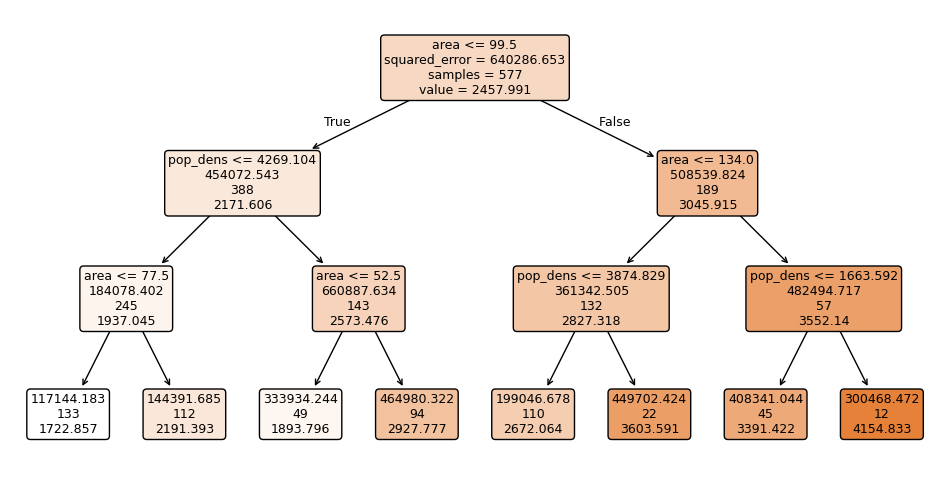

In [66]:
fig = plt.figure(figsize=(12,6))
_ = tree.plot_tree(reg, 
                   feature_names=list(X_train.columns),  
                   class_names=['price'],
                   filled=True,
                   fontsize=9,
                   label='root',
                   rounded=True)

## Random Forest Regression
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### Create train and test samples for the random forest (train = 80%, test = 20% of the data)

In [67]:
# Create train and test samples (the names X2_ and y2_ were used because X_ and y_ were already used above)
X2_train, X2_test, y2_train, y2_test = train_test_split(df[['area', 
                                                            'rooms',
                                                            'pop_dens',
                                                            'mean_taxable_income',
                                                            'dist_supermarket']], 
                                                            df['price'], 
                                                            test_size=0.20, 
                                                            random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
     area  rooms     pop_dens  mean_taxable_income  dist_supermarket
456   120    6.5   165.018625          65380.98802       1958.318650
6      65    3.5   525.662252         111422.35870        282.095910
362    90    3.5   424.146342          72133.75058       2606.231069
594    63    2.5  1044.628957          70964.08794        564.607066
439    91    3.5   399.525129          62000.54187        646.823905 

y2_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the Random Forest Regression

In [68]:
X, y = make_regression(n_features=4, n_informative=2,
                       random_state=5, shuffle=False)


reg_rf = RandomForestRegressor(n_estimators=500, 
                               max_depth=10, 
                               random_state=5)
reg_rf.fit(X2_train, y2_train)

# Calculate coefficient of determination (R-squared)
print(f'R-squared: {reg_rf.score(X2_test, y2_test):.4f}')

R-squared: 0.5481


### Show feature importance

Index(['area', 'pop_dens', 'dist_supermarket', 'mean_taxable_income', 'rooms'], dtype='object')
[0.56749536 0.16751781 0.11611526 0.09147853 0.05739305]


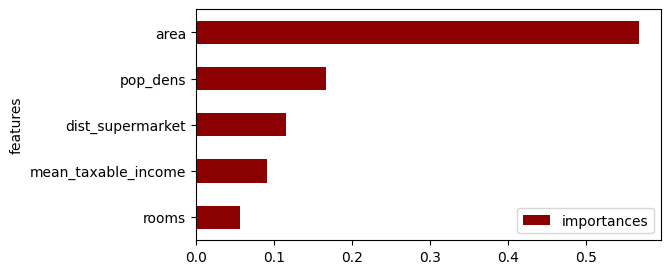

In [69]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = reg_rf.feature_importances_
std         = np.std([tree.feature_importances_ for tree in reg_rf.estimators_], axis=0)
indices     = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh', 
           y='importances', 
           x='features', 
           color='darkred', 
           figsize=(6,3))

plt.show()

### b) Change the model parameter max_depth=3 to max_depth=5. This will change the depth (complexity) of the tree. Compare the output (text and graphic) with the output of the original regression tree (in which max_depth=3). Do you see any differences? In the Jupyter notebook, explain why.

### Fit the regression tree model

In [70]:
b_reg = DecisionTreeRegressor(random_state=20, max_depth=5)
b_reg = b_reg.fit(X_train, y_train)
b_y_pred = b_reg.predict(X_test)

### Calculate coefficient of determination (R-squared)

In [71]:
print(f'R-squared:, {r2_score(y_test, b_y_pred):.4f}')

R-squared:, 0.5247


### Print text representation of the regression tree

In [72]:
# Text representation of the regression tree
text_representation = tree.export_text(b_reg,
                                       feature_names=list(X_train.columns))

# Print text_representation
print(text_representation)

|--- area <= 99.50
|   |--- pop_dens <= 4269.10
|   |   |--- area <= 77.50
|   |   |   |--- rooms <= 1.25
|   |   |   |   |--- area <= 35.50
|   |   |   |   |   |--- value: [1153.83]
|   |   |   |   |--- area >  35.50
|   |   |   |   |   |--- value: [1325.00]
|   |   |   |--- rooms >  1.25
|   |   |   |   |--- area <= 69.50
|   |   |   |   |   |--- value: [1698.66]
|   |   |   |   |--- area >  69.50
|   |   |   |   |   |--- value: [1884.28]
|   |   |--- area >  77.50
|   |   |   |--- mean_taxable_income <= 96728.41
|   |   |   |   |--- pop_dens <= 1030.49
|   |   |   |   |   |--- value: [1995.61]
|   |   |   |   |--- pop_dens >  1030.49
|   |   |   |   |   |--- value: [2257.40]
|   |   |   |--- mean_taxable_income >  96728.41
|   |   |   |   |--- mean_taxable_income <= 166929.42
|   |   |   |   |   |--- value: [2604.00]
|   |   |   |   |--- mean_taxable_income >  166929.42
|   |   |   |   |   |--- value: [3055.00]
|   |--- pop_dens >  4269.10
|   |   |--- area <= 52.50
|   |   |   |---

### Vizualizing the regression tree

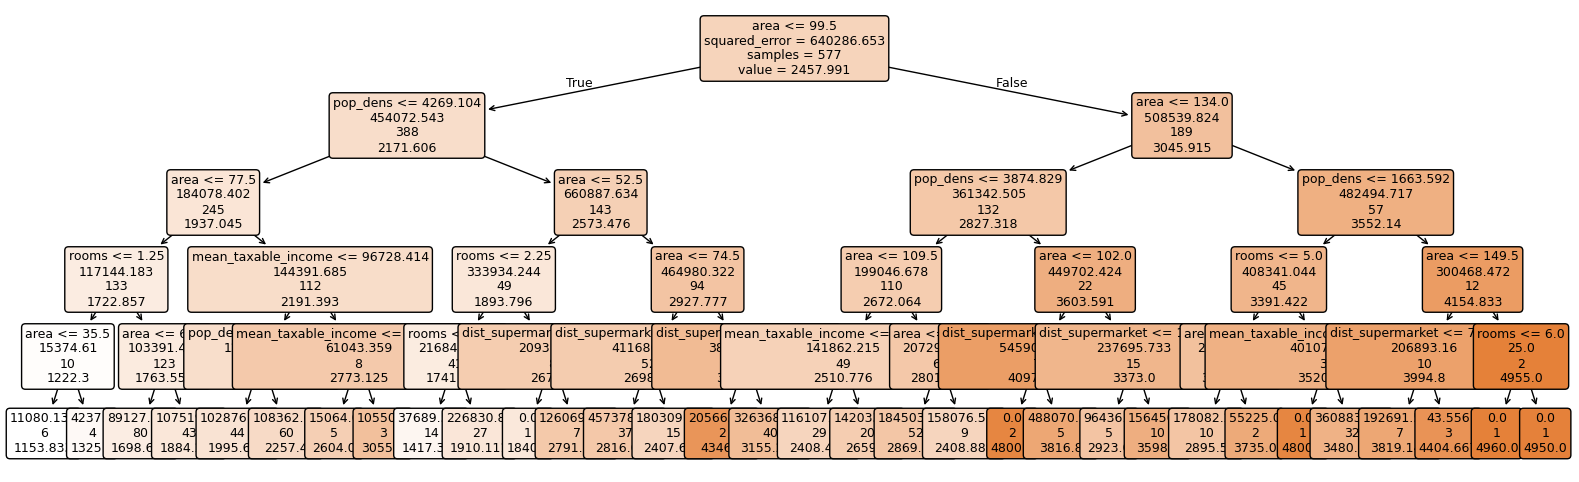

In [73]:
fig = plt.figure(figsize=(20,6))
_ = tree.plot_tree(b_reg,
                   feature_names=list(X_train.columns),
                   class_names=['price'],
                   filled=True,
                   fontsize=9,
                   label='root',
                   rounded=True)

### b) Interpretation

The regression tree with max_depth=5 is more complex than the one with max_depth=3. It has more splits, which allows it to capture more nuances in the data. However, this increased complexity can lead to overfitting, where the model performs well on the training data but poorly on unseen data. The R-squared value may improve slightly, but it is essential to validate the model's performance on a separate test set to ensure it generalizes well. Also, R-squared changed from 0.4502 (max_depth=3) to 0.5247 (max_depth=5), indicating a better fit to the training data, but caution is needed to avoid overfitting.

### c) Drop the two variables area and rooms from the train and test samples. Run the Jupyter notebook again. Does the R-squared value change? If so, explain why in the Jupyter notebook.

### Create train and test samples for the random forest (train = 80%, test = 20% of the data)

In [74]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df[['pop_dens',
                                                        'mean_taxable_income',
                                                        'dist_supermarket']],
                                                        df['price'],
                                                        test_size=0.20,
                                                        random_state=42)

# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
        pop_dens  mean_taxable_income  dist_supermarket
456   165.018625          65380.98802       1958.318650
6     525.662252         111422.35870        282.095910
362   424.146342          72133.75058       2606.231069
594  1044.628957          70964.08794        564.607066
439   399.525129          62000.54187        646.823905 

y_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the regression tree model

In [75]:
c_reg = DecisionTreeRegressor(random_state=20, max_depth=5)
c_reg = c_reg.fit(X_train, y_train)
c_y_pred = c_reg.predict(X_test)

### Calculate coefficient of determination (R-squared)

In [76]:
print(f'R-squared:, {r2_score(y_test, c_y_pred):.4f}')

R-squared:, 0.0192


### c) Interpretation

By dropping the variables 'area' and 'rooms', the R-squared value decreased from 0.5247 (with all variables) to 0.0192 (without 'area' and 'rooms'). This indicates that 'area' and 'rooms' are significant predictors of apartment prices. Their absence reduces the model's ability to explain the variance in prices, leading to a lower R-squared value. This highlights the importance of these features in predicting apartment prices accurately.

### d) Go to the section ‘Show feature importance’ of the random forest and look at the barchart. Note that ‘features’ is another name for the ‘explanatory variables’ in a Machine Learning (ML) model.

I've taken a look - looks good!

### e) Go to the section ‘Create train and test samples’ and drop the variable area. Run the Jupyter notebook again.

### Create train and test samples for the random forest (train = 80%, test = 20% of the data)

In [77]:
# Create train and test samples (the names X2_ and y2_ were used because X_ and y_ were already used above)
X2_train, X2_test, y2_train, y2_test = train_test_split(df[['rooms',
                                                            'pop_dens',
                                                            'mean_taxable_income',
                                                            'dist_supermarket']],
                                                            df['price'],
                                                            test_size=0.20,
                                                            random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
     rooms     pop_dens  mean_taxable_income  dist_supermarket
456    6.5   165.018625          65380.98802       1958.318650
6      3.5   525.662252         111422.35870        282.095910
362    3.5   424.146342          72133.75058       2606.231069
594    2.5  1044.628957          70964.08794        564.607066
439    3.5   399.525129          62000.54187        646.823905 

y2_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the Random Forest Regression

In [78]:
X, y = make_regression(n_features=4, n_informative=2,
                       random_state=5, shuffle=False)


reg_rf = RandomForestRegressor(n_estimators=500,
                               max_depth=10,
                               random_state=5)
reg_rf.fit(X2_train, y2_train)

# Calculate coefficient of determination (R-squared)
print(f'R-squared: {reg_rf.score(X2_test, y2_test):.4f}')

R-squared: 0.3215


### Show feature importance

Index(['rooms', 'dist_supermarket', 'mean_taxable_income', 'pop_dens'], dtype='object')
[0.39736226 0.27042968 0.17860647 0.15360159]


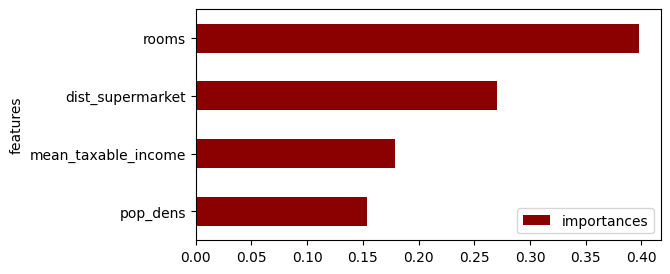

In [79]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = reg_rf.feature_importances_
std         = np.std([tree.feature_importances_ for tree in reg_rf.estimators_], axis=0)
indices     = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh',
           y='importances',
           x='features',
           color='darkred',
           figsize=(6,3))

plt.show()

### f) Does the importance of features change? If yes, explain why in the Jupyter notebook.

Yes, the importance of features changed after dropping the 'area' variable. In the original model, 'area' was likely one of the most important features for predicting apartment prices. After removing it, the model had to rely more heavily on the remaining features ('rooms', 'pop_dens', 'mean_taxable_income', and 'dist_supermarket'). As a result, the importance scores for these features may have increased, reflecting their increased contribution to the model's predictions. This change highlights how feature importance is relative and can be influenced by the presence or absence of other features in the dataset.

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [80]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
NT
Windows | 11
Datetime: 2025-11-11 19:35:03
Python Version: 3.13.7
-----------------------------------
